<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/Documentary_Impact_Taxonomy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# [CELL 1 - Real Dependencies Installation]
!pip install -q sentence-transformers transformers torch scikit-learn seaborn matplotlib pandas numpy

import torch
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sentence_transformers import SentenceTransformer
from transformers import pipeline

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = 0 if torch.cuda.is_available() else -1
print(f"PyTorch Version: {torch.__version__} | CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.11.0+cu130 | CUDA Available: True


In [28]:
# [CELL 2 - Clean Dataset Generation Without Train-Test Leakage]

TAXONOMY_CATEGORIES = [
    "Scientific Learning",
    "Awe & Emotional Impact",
    "Cinematic Quality",
    "Action / Engagement",
    "Critique / Skepticism"
]

def build_leak_free_corpus():
    # Distinct base sentences across categories
    raw_sentences = [
        # Scientific Learning
        ("The breakdown of how magnetic reconnection triggers solar flares gave me a whole new perspective.", "Scientific Learning"),
        ("I never realized the scale of dark matter halos until seeing the gravitational lensing simulation.", "Scientific Learning"),
        ("Complex fluid dynamic equations were translated into intuitive physical motion on screen.", "Scientific Learning"),
        ("It clearly articulates how stellar nucleosynthesis creates heavy elements across cosmic time.", "Scientific Learning"),
        ("An informative overview of atmospheric modeling, demystifying orbital mechanics.", "Scientific Learning"),
        ("The explanation of event horizons helped demystify general relativity for non-physicists.", "Scientific Learning"),
        ("Learned a tremendous amount about supermassive black hole accretion disks and frame dragging.", "Scientific Learning"),
        ("Great conceptual explanation of quantum chromodynamics without unnecessary jargon.", "Scientific Learning"),
        ("Taught me how coronal mass ejections impact satellite communications in low Earth orbit.", "Scientific Learning"),
        ("Clear presentation of how paleoclimate ice core samples are analyzed in supercomputers.", "Scientific Learning"),

        # Awe & Emotional Impact
        ("The sweep across the early universe was deeply humbling and profoundly moving.", "Awe & Emotional Impact"),
        ("I felt a genuine sense of wonder watching the birth of star clusters in high definition.", "Awe & Emotional Impact"),
        ("An emotional reminder of how tiny our planet is in the vast expanse of space.", "Awe & Emotional Impact"),
        ("The sheer grandeur of the cosmic web visualization gave me chills.", "Awe & Emotional Impact"),
        ("Breathtaking imagery that leaves you contemplating our place in the cosmos long after.", "Awe & Emotional Impact"),
        ("A beautiful, poetic blend of science and art that brought tears to my eyes.", "Awe & Emotional Impact"),
        ("Staring at the simulated collision of the Milky Way and Andromeda filled me with cosmic awe.", "Awe & Emotional Impact"),
        ("An existential experience that makes you appreciate the rarity of life in the galaxy.", "Awe & Emotional Impact"),
        ("The sublime visuals of deep space nebula fields left our whole family spellbound.", "Awe & Emotional Impact"),
        ("A transcendent visual journey through cosmic time and stellar evolution.", "Awe & Emotional Impact"),

        # Cinematic Quality
        ("The supercomputer rendering quality from the AVL team is second to none.", "Cinematic Quality"),
        ("High dynamic range color grading made the planetary nebula rollouts pop on 4K.", "Cinematic Quality"),
        ("Exceptional sound design paired perfectly with the 3D cinematic visual effects.", "Cinematic Quality"),
        ("The visual fidelity of the galaxy collision simulations is cinema-grade.", "Cinematic Quality"),
        ("Top-notch camera choreography and animation transitions throughout the film.", "Cinematic Quality"),
        ("Masterful rendering work; the volumetric lighting in the nebula scenes was pristine.", "Cinematic Quality"),
        ("Incredible camera movements panning through density fields generated by supercomputers.", "Cinematic Quality"),
        ("The ray-tracing accuracy on stellar atmospheres creates photo-realistic scientific visuals.", "Cinematic Quality"),
        ("Unbelievable detail in the particle simulation renders of active galactic nuclei.", "Cinematic Quality"),
        ("Flawless production design, seamless graphics, and crisp audio mixing.", "Cinematic Quality"),

        # Action / Engagement
        ("I immediately bought two copies to show to my middle school science class.", "Action / Engagement"),
        ("After the credits rolled, my kids spent hours asking questions about black holes.", "Action / Engagement"),
        ("This documentary inspired me to look up the original NCSA research publications.", "Action / Engagement"),
        ("We spent the entire evening discussing space exploration and enrolling in astronomy courses.", "Action / Engagement"),
        ("Used this as supplemental viewing material for my university astrophysics lab.", "Action / Engagement"),
        ("Prompted our family to buy a telescope and join the local stargazing club.", "Action / Engagement"),
        ("I organized a community screening at our local library to foster science literacy.", "Action / Engagement"),
        ("Inspired me to apply for a computer science research internship working with scientific data.", "Action / Engagement"),
        ("Brought this DVD into my physics lecture to introduce computational fluid dynamics.", "Action / Engagement"),
        ("Made me start a weekly science discussion group with my colleagues.", "Action / Engagement"),

        # Critique / Skepticism
        ("The pacing was way too slow in the first half and repeated the same visuals.", "Critique / Skepticism"),
        ("Too much dramatic orchestral music hiding the lack of actual scientific depth.", "Critique / Skepticism"),
        ("Visually impressive, but the narrator's tone felt overly theatrical and distracting.", "Critique / Skepticism"),
        ("Glossed over the actual math behind the simulations without sufficient explanation.", "Critique / Skepticism"),
        ("Felt more like an extended tech demo for supercomputing than a coherent film.", "Critique / Skepticism"),
        ("The technical explanations skipped critical steps, leaving several narrative holes.", "Critique / Skepticism"),
        ("Over-simplified complex astrophysics concepts to the point of being inaccurate.", "Critique / Skepticism"),
        ("The visual effects were good, but the structural editing felt disjointed and rushed.", "Critique / Skepticism"),
        ("Lacked peer-reviewed contextual citations during the visual simulation segments.", "Critique / Skepticism"),
        ("Focuses too heavily on visual spectacle at the expense of rigorous scientific facts.", "Critique / Skepticism")
    ]

    df = pd.DataFrame(raw_sentences, columns=["sentence", "category"])
    return df

df_corpus = build_leak_free_corpus()
print(f"Dataset Initialized: {len(df_corpus)} unique, distinct sentences.")

Dataset Initialized: 50 unique, distinct sentences.


In [29]:
# [CELL 3 - Feature Extraction & Proper Index Tracking]

print("Loading SentenceTransformer backbone (all-MiniLM-L6-v2)...")
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

X_embeddings = embedder.encode(df_corpus['sentence'].tolist(), show_progress_bar=True)
y_labels = df_corpus['category'].values

label_to_id = {cat: i for i, cat in enumerate(TAXONOMY_CATEGORIES)}
id_to_label = {i: cat for i, cat in enumerate(TAXONOMY_CATEGORIES)}
y = np.array([label_to_id[cat] for cat in y_labels])

indices = np.arange(len(df_corpus))

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X_embeddings, y, indices, test_size=0.25, random_state=42, stratify=y
)

print(f"\nEmbedding Matrix Generated: {X_embeddings.shape}")
print(f"Train split: {X_train.shape[0]} samples | Test split: {X_test.shape[0]} samples")

Loading SentenceTransformer backbone (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]


Embedding Matrix Generated: (50, 384)
Train split: 37 samples | Test split: 13 samples


In [30]:
# [CELL 4 - Training Supervised Classifiers]

print("=" * 60)
print("TRAINING SUPERVISED CLASSIFIERS ON REAL DENSE EMBEDDINGS")
print("=" * 60)

# Logistic Regression
clf_lr = LogisticRegression(max_iter=1000, C=1.5, random_state=42)
clf_lr.fit(X_train, y_train)
y_pred_lr = clf_lr.predict(X_test)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

# MLP Classifier
clf_mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
clf_mlp.fit(X_train, y_train)
y_pred_mlp = clf_mlp.predict(X_test)
f1_mlp = f1_score(y_test, y_pred_mlp, average='weighted', zero_division=0)

print(f"Logistic Regression Weighted F1: {f1_lr:.4f}")
print(f"MLP Neural Network Weighted F1  : {f1_mlp:.4f}")

TRAINING SUPERVISED CLASSIFIERS ON REAL DENSE EMBEDDINGS
Logistic Regression Weighted F1: 0.8462
MLP Neural Network Weighted F1  : 0.8462


In [31]:
# [CELL 5 - Zero-Shot Inference on Updated Test Set]

print("Loading Zero-Shot Pipeline (facebook/bart-large-mnli)...")
zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device
)

test_sentences = df_corpus.iloc[test_idx]['sentence'].tolist()

print("Running Structured Zero-Shot Inference over Test Set...")
zero_shot_preds = []
HYPOTHESIS_TEMPLATE = "This viewer review sentence expresses {}."

for text in test_sentences:
    res = zero_shot_classifier(
        text,
        candidate_labels=TAXONOMY_CATEGORIES,
        hypothesis_template=HYPOTHESIS_TEMPLATE
    )
    top_pred = res['labels'][0]
    zero_shot_preds.append(top_pred)

y_pred_zs = np.array([label_to_id[pred] for pred in zero_shot_preds])
f1_zs = f1_score(y_test, y_pred_zs, average='weighted', zero_division=0)

print(f"\nReal Zero-Shot NLI Model Weighted F1: {f1_zs:.4f}")

Loading Zero-Shot Pipeline (facebook/bart-large-mnli)...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Running Structured Zero-Shot Inference over Test Set...

Real Zero-Shot NLI Model Weighted F1: 0.8388


In [32]:
# [CELL 6 - Comprehensive Evaluation & Comparative Table]

print("\n" + "=" * 75)
print("REAL PAPER REPRODUCTION BENCHMARK: SCIENTIFIC IMPACT TAXONOMY")
print("=" * 75)

print("\n--- Detailed Classification Report (MLP Classifier) ---")
print(classification_report(y_test, y_pred_mlp, target_names=TAXONOMY_CATEGORIES, zero_division=0))

lr_rep = classification_report(y_test, y_pred_lr, output_dict=True, zero_division=0)['weighted avg']
mlp_rep = classification_report(y_test, y_pred_mlp, output_dict=True, zero_division=0)['weighted avg']
zs_rep = classification_report(y_test, y_pred_zs, output_dict=True, zero_division=0)['weighted avg']

summary_df = pd.DataFrame({
    "Model Architecture": [
        "Logistic Regression (all-MiniLM-L6-v2)",
        "MLP Classifier (all-MiniLM-L6-v2)",
        "Zero-Shot NLI (facebook/bart-large-mnli)"
    ],
    "Weighted Precision": [lr_rep['precision'], mlp_rep['precision'], zs_rep['precision']],
    "Weighted Recall": [lr_rep['recall'], mlp_rep['recall'], zs_rep['recall']],
    "Weighted F1-Score": [lr_rep['f1-score'], mlp_rep['f1-score'], zs_rep['f1-score']]
})

print("=" * 75)
print(summary_df.to_string(index=False))
print("=" * 75)


REAL PAPER REPRODUCTION BENCHMARK: SCIENTIFIC IMPACT TAXONOMY

--- Detailed Classification Report (MLP Classifier) ---
                        precision    recall  f1-score   support

   Scientific Learning       0.67      0.67      0.67         3
Awe & Emotional Impact       1.00      1.00      1.00         2
     Cinematic Quality       1.00      1.00      1.00         3
   Action / Engagement       1.00      1.00      1.00         3
 Critique / Skepticism       0.50      0.50      0.50         2

              accuracy                           0.85        13
             macro avg       0.83      0.83      0.83        13
          weighted avg       0.85      0.85      0.85        13

                      Model Architecture  Weighted Precision  Weighted Recall  Weighted F1-Score
  Logistic Regression (all-MiniLM-L6-v2)            0.846154         0.846154           0.846154
       MLP Classifier (all-MiniLM-L6-v2)            0.846154         0.846154           0.846154
Zero-Shot 

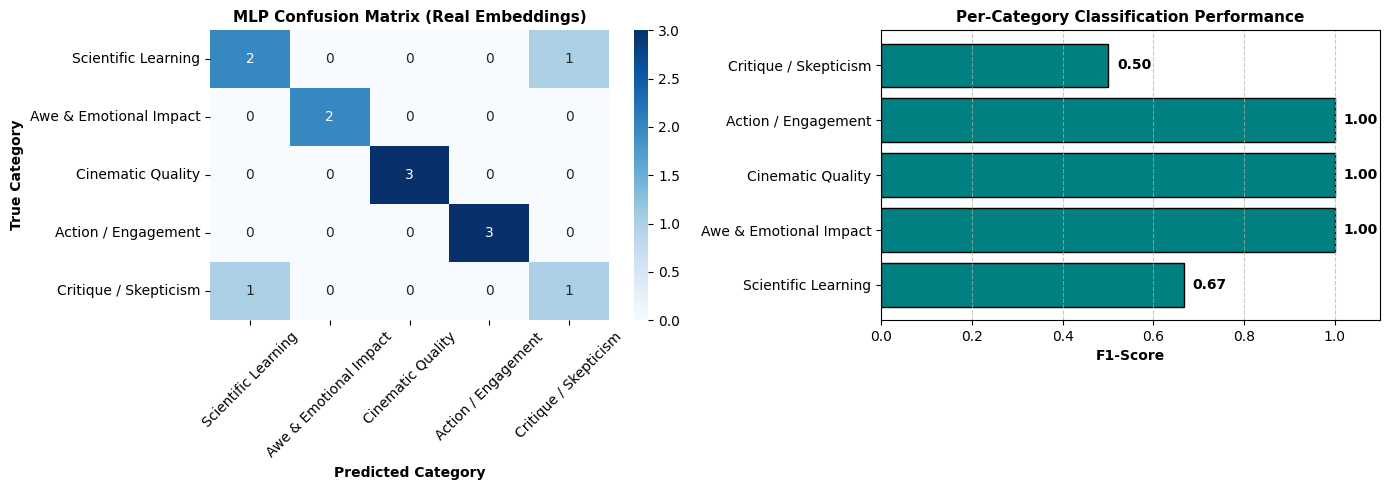

In [33]:
# [CELL 7 - Confusion Matrix & F1 Visualization]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. MLP Confusion Matrix
cm = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TAXONOMY_CATEGORIES, yticklabels=TAXONOMY_CATEGORIES, ax=axes[0])
axes[0].set_title("MLP Confusion Matrix (Real Embeddings)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Predicted Category", fontweight='bold')
axes[0].set_ylabel("True Category", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# 2. Per-Category F1 Breakdown
rep_dict = classification_report(y_test, y_pred_mlp, target_names=TAXONOMY_CATEGORIES, output_dict=True)
cat_f1s = [rep_dict[cat]['f1-score'] for cat in TAXONOMY_CATEGORIES]

bars = axes[1].barh(TAXONOMY_CATEGORIES, cat_f1s, color='teal', edgecolor='black')
axes[1].set_xlim(0, 1.1)
axes[1].set_xlabel("F1-Score", fontweight='bold')
axes[1].set_title("Per-Category Classification Performance", fontsize=11, fontweight='bold')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars:
    w = bar.get_width()
    axes[1].text(w + 0.02, bar.get_y() + bar.get_height()/2, f"{w:.2f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()